**IMPORT LIBARIES**


In [ ]:
import os
import pickle as pkl
import multiprocessing as mp
import random
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import Tensor
from torch.utils.data import DataLoader, Sampler, Dataset
from torch.nn.utils.rnn import pad_sequence
from torch.nn.utils import clip_grad_norm_
from torch.distributions.uniform import Uniform
from torch.optim.lr_scheduler import ReduceLROnPlateau
from datasets import load_from_disk, Dataset
from os.path import join
from typing import List, Iterator, Literal
from tqdm.auto import tqdm
import nltk
import distance
import matplotlib.pyplot as plt
import albumentations as alb
from albumentations.pytorch import ToTensorV2


os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

**GLOBAL CONFIGURATIONS**


In [3]:
NUM_WORKERS = mp.cpu_count()

In [ ]:
class Config:
    data_path = "/kaggle/input/im2latex-100k/dataset"
    vocab_path = "/kaggle/input/im2latex-100k/vocab.pkl"
    save_dir = "./Checkpoint"

    # Model args
    d_model = 512
    n_heads = 8
    n_layers = 8
    d_ff = 1024
    max_len = 150

    # Training args
    dropout = 0.2
    cuda = True
    batch_size = 32
    accumulation_steps = 1
    epoches = 100
    lr = 1e-4
    min_lr = 1e-5
    label_smoothing = 0.1

    # Sampling & Decay
    sample_method = (
        "teacher_forcing"  # choices: 'teacher_forcing', 'exp', 'inv_sigmoid'
    )
    decay_k = None
    lr_decay = 0.5
    lr_patience = 2
    clip = 1.0

    # Learning rate warmup
    warmup_lr = 2e-5
    warmup_epochs = 2

    # Early stopping
    es_patience = 6
    es_min_delta = 1e-3

    # Misc
    seed = 2026

    # Checkpoint settings
    from_check_point = False
    checkpoint_path = "/kaggle/input/test-crnn-aug/pytorch/default/1"

    # Evaluation
    result_path = "./Result.txt"
    ref_path = "./Ref.txt"
    eval_batch_size = 32
    beam_size = 5

In [ ]:
def seed_everything(seed):
    # 1. Python & Numpy
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    np.random.seed(seed)

    # 2. PyTorch
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        if torch.cuda.device_count() > 1:
            torch.cuda.manual_seed_all(seed)

    # 3. CuDNN
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

In [6]:
args = Config()
if args.seed is not None:
    seed_everything(args.seed)

use_cuda = True if args.cuda and torch.cuda.is_available() else False
device = torch.device("cuda" if use_cuda else "cpu")
print(f"Using device: {device}")

Using device: cuda


# 1. DATA PREPARATION


## 1.1. Configurations


In [ ]:
START_TOKEN_ID = 0
PAD_TOKEN_ID = 1
END_TOKEN_ID = 2
UNK_TOKEN_ID = 3

## 1.2. Load data


### 1.2.1. Utils


In [8]:
class Vocab:
    def __init__(self):
        self.sign2id = {
            "<s>": START_TOKEN_ID,
            "</s>": END_TOKEN_ID,
            "<pad>": PAD_TOKEN_ID,
            "<unk>": UNK_TOKEN_ID,
        }
        self.id2sign = dict((idx, token) for token, idx in self.sign2id.items())
        self.length = 4

    def add_sign(self, sign):
        if sign not in self.sign2id:
            self.sign2id[sign] = self.length
            self.id2sign[self.length] = sign
            self.length += 1

    def __len__(self) -> int:
        return self.length

In [9]:
def load_vocab(filepath: str) -> Vocab:
    with open(filepath, "rb") as f:
        vocab: Vocab = pkl.load(f)
    print(f"Load vocab including {len(vocab)} Latex tokens.")
    return vocab

### 1.2.2. Load data


In [10]:
vocab = load_vocab(args.vocab_path)
vocab_size = len(vocab)

Load vocab including 394 Latex tokens.


## 1.3. Create DataLoader


### 1.3.1 Utils


In [ ]:
train_transform = alb.Compose(
    [
        # Padding
        alb.PadIfNeeded(
            min_height=None,
            min_width=None,
            position="center",
            pad_height_divisor=16,
            pad_width_divisor=16,
            border_mode=0,
            fill=[255, 255, 255],
        ),
        # Geometric
        alb.Compose(
            [
                alb.Affine(
                    scale=(0.8, 1.05),
                    rotate=(-2, 2),
                    shear=(-2, 2),
                    border_mode=0,
                    interpolation=4,
                    fill=[255, 255, 255],
                    p=0.5,
                ),
                alb.Perspective(
                    scale=(0.005, 0.018), border_mode=0, fill=[0, 0, 0], p=0.5
                ),
            ],
            p=0.5,
        ),
        # Font thickness
        alb.OneOf(
            [
                alb.Morphological(scale=[1, 2], operation="erosion", p=1.0),
                alb.Morphological(scale=[1, 1.5], operation="dilation", p=1.0),
            ],
            p=0.6,
        ),
        # Color variations TRƯỚC khi ToGray - để tạo diversity trong grayscale
        alb.HueSaturationValue(
            hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.5
        ),
        # Lighting variations
        alb.RandomBrightnessContrast(
            brightness_limit=0.1, contrast_limit=(-0.3, 0.1), p=0.7
        ),
        # Quality degradation
        alb.ImageCompression(quality_range=(85, 95), p=0.5),
        alb.Downscale(
            scale_range=[0.7, 0.95],
            interpolation_pair={"upscale": 4, "downscale": 3},
            p=0.3,
        ),
        # Noise and blur
        alb.GaussNoise(std_range=(0.02, 0.17), p=0.2),
        alb.GaussianBlur(sigma_limit=(0.1, 0.5), p=0.3),
        # Convert to grayscale
        alb.ToGray(p=1.0),
        alb.Normalize(mean=(0.9491, 0.9491, 0.9491), std=(0.1846, 0.1846, 0.1846)),
        ToTensorV2(),
    ],
    seed=args.seed,
)

test_transform = alb.Compose(
    [
        alb.PadIfNeeded(
            min_height=None,
            min_width=None,
            position="center",
            pad_height_divisor=16,
            pad_width_divisor=16,
            border_mode=0,
            fill=[255, 255, 255],
        ),
        alb.ToGray(p=1.0),
        alb.Normalize((0.9491, 0.9491, 0.9491), (0.1846, 0.1846, 0.1846)),
        ToTensorV2(),
    ]
)


def train_transforms(batch):
    images = []
    for img in batch["image"]:
        img_array = np.array(img)
        augmented = train_transform(image=img_array)
        images.append(augmented["image"])
    batch["image"] = images
    return batch


def test_transforms(batch):
    images = []
    for img in batch["image"]:
        img_array = np.array(img)
        augmented = test_transform(image=img_array)
        images.append(augmented["image"])
    batch["image"] = images
    return batch

In [ ]:
class SmartBucketSampler(Sampler):
    def __init__(
        self,
        data_source: Dataset,
        batch_size: int,
        shuffle: bool = True,
        drop_last: bool = False,
        seed: int = None,
    ):
        self.data_source = data_source
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.drop_last = drop_last
        self.seed = seed
        self.epoch = 0

        self.buckets = {}

        print("Initializing Sampler... (Loading sizes)")

        widths = data_source["width"]
        heights = data_source["height"]

        # Build buckets
        for idx, (w, h) in enumerate(zip(widths, heights)):
            key = (w, h)
            if key not in self.buckets:
                self.buckets[key] = []
            self.buckets[key].append(idx)

        for key in self.buckets:
            self.buckets[key] = np.array(self.buckets[key], dtype=np.int32)

        print(f"Sampler initialized. Found {len(self.buckets)} unique buckets.")

        # Pre-compute bucket sizes
        self.bucket_sizes = {key: len(indices) for key, indices in self.buckets.items()}

        # Tính total_batches hiệu quả
        self.total_batches = sum(
            (size + (0 if self.drop_last else self.batch_size - 1)) // self.batch_size
            for size in self.bucket_sizes.values()
        )

    def __iter__(self) -> Iterator[List[int]]:
        # Tạo random generators
        if self.seed is not None:
            generator_seed = self.seed + self.epoch
            rng = random.Random(generator_seed)
            np_rng = np.random.RandomState(generator_seed)
        else:
            rng = random.Random()
            np_rng = np.random.RandomState()

        bucket_keys = list(self.buckets.keys())
        if self.shuffle:
            rng.shuffle(bucket_keys)

        batches = []

        for key in bucket_keys:
            # Copy numpy array
            indices = self.buckets[key].copy()

            if self.shuffle:
                np_rng.shuffle(indices)

            # Tạo batches
            num_samples = len(indices)
            for i in range(0, num_samples, self.batch_size):
                end_idx = min(i + self.batch_size, num_samples)
                batch = indices[i:end_idx].tolist()

                if len(batch) == self.batch_size or not self.drop_last:
                    batches.append(batch)

        if self.shuffle:
            rng.shuffle(batches)

        yield from batches

    def __len__(self) -> int:
        return self.total_batches

    def set_epoch(self, epoch: int) -> None:
        self.epoch = epoch

In [ ]:
def collate_fn(batch):
    imgs = [item["image"] for item in batch]
    formulas = []

    for item in batch:
        tokens = item["formula"].split()
        formula_indices = [
            vocab.sign2id.get(token, vocab.sign2id["<unk>"]) for token in tokens
        ]
        formula_indices = (
            [vocab.sign2id["<s>"]] + formula_indices + [vocab.sign2id["</s>"]]
        )
        formulas.append(torch.tensor(formula_indices, dtype=torch.long))

    imgs = torch.stack(imgs)
    formulas = pad_sequence(
        formulas, batch_first=True, padding_value=vocab.sign2id["<pad>"]
    )

    return imgs, formulas

### 1.3.2. Setup sampler


In [14]:
processed_dataset = load_from_disk(args.data_path)

In [ ]:
train_dataset = processed_dataset["train"]
val_dataset = processed_dataset["validation"]
test_dataset = processed_dataset["test"]

train_dataset.set_transform(train_transforms)
val_dataset.set_transform(test_transforms)
test_dataset.set_transform(test_transforms)

In [ ]:
train_sampler = SmartBucketSampler(
    processed_dataset["train"],
    batch_size=args.batch_size,
    shuffle=True,
    drop_last=True,
    seed=args.seed,
)

val_sampler = SmartBucketSampler(
    processed_dataset["validation"],
    batch_size=args.batch_size,
    shuffle=False,
    drop_last=False,
    seed=args.seed,
)

test_sampler = SmartBucketSampler(
    processed_dataset["test"],
    batch_size=args.eval_batch_size,
    shuffle=False,
    drop_last=False,
    seed=args.seed,
)

Initializing Sampler... (Loading sizes)
Sampler initialized. Found 19 unique buckets.
Initializing Sampler... (Loading sizes)
Sampler initialized. Found 19 unique buckets.
Initializing Sampler... (Loading sizes)
Sampler initialized. Found 22 unique buckets.


### 1.3.3. DataLoader


In [17]:
def seed_worker(worker_id: int):
    worker_seed = (torch.initial_seed() + worker_id) % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [ ]:
worker_init = seed_worker if (args.seed is not None) else None

train_loader = DataLoader(
    train_dataset,
    batch_sampler=train_sampler,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=True if use_cuda else False,
    worker_init_fn=worker_init,
    persistent_workers=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_sampler=val_sampler,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=True if use_cuda else False,
    worker_init_fn=worker_init,
)

test_loader = DataLoader(
    test_dataset,
    batch_sampler=test_sampler,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=True if use_cuda else False,
    worker_init_fn=worker_init,
)

# 2. IM2LATEX MODEL


## 2.2. Positional Encoding


In [ ]:
class PositionalEncoding2D(nn.Module):
    def __init__(self, d_model: int, max_h: int = 200, max_w: int = 200):
        super().__init__()
        if d_model % 4 != 0:
            raise ValueError(f"d_model must be divisible by 4 for 2D PE, got {d_model}")

        self.d_model = d_model
        d_half = d_model // 2  # Mỗi chiều H, W chiếm một nửa d_model

        pe = torch.zeros(d_model, max_h, max_w)

        # div_term cho sin/cos: shape [d_half // 2] -> [128] nếu d_model=512
        div_term = torch.exp(
            torch.arange(0, d_half, 2).float() * (-math.log(10000.0) / d_half)
        )

        pos_h = torch.arange(0, max_h).unsqueeze(1).float()  # [max_h, 1]
        pos_w = torch.arange(0, max_w).unsqueeze(1).float()  # [max_w, 1]

        # --- Mã hóa cho chiều Cao (H) ---
        # Tính toán sin/cos: [max_h, d_half // 2]
        sin_h = torch.sin(pos_h * div_term)
        cos_h = torch.cos(pos_h * div_term)

        # Chuyển đổi về [d_half // 2, max_h, 1] để broadcast với chiều W
        # Sau đó gán vào pe. PyTorch sẽ tự động broadcast chiều W (max_w)
        pe[0:d_half:2, :, :] = sin_h.transpose(0, 1).unsqueeze(2)
        pe[1:d_half:2, :, :] = cos_h.transpose(0, 1).unsqueeze(2)

        # --- Mã hóa cho chiều Rộng (W) ---
        # Tính toán sin/cos: [max_w, d_half // 2]
        sin_w = torch.sin(pos_w * div_term)
        cos_w = torch.cos(pos_w * div_term)

        # Chuyển đổi về [d_half // 2, 1, max_w] để broadcast với chiều H
        pe[d_half::2, :, :] = sin_w.transpose(0, 1).unsqueeze(1)
        pe[d_half + 1 :: 2, :, :] = cos_w.transpose(0, 1).unsqueeze(1)

        self.register_buffer("pe", pe.unsqueeze(0))  # Shape: [1, d_model, max_h, max_w]

    def forward(self, x):
        """
        Args:
            x: Tensor shape [batch_size, d_model, H, W]
        """
        # Cộng PE vào input
        return x + self.pe[:, :, : x.size(2), : x.size(3)]

In [ ]:
class PositionalEncoding1D(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        """
        Args:
            x: [B, seq_len, d_model]
        """
        return x + self.pe[:, : x.size(1), :]

## 2.3 Encoder


In [ ]:
class Encoder(nn.Module):
    def __init__(self, enc_out_dim: int, dropout: float) -> None:
        super().__init__()

        self.cnn_encoder = nn.Sequential(
            ### Block 1
            nn.Conv2d(3, 64, 3, 1, 1),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),
            ###
            ### Block 2
            nn.Conv2d(64, 128, 3, 1, 1),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),
            ###
            ### Block 3
            nn.Conv2d(128, 256, 3, 1, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            ###
            ### Block 4
            nn.Conv2d(256, 256, 3, 1, 1),
            nn.ReLU(True),
            nn.MaxPool2d((1, 2), (1, 2)),
            ###
            ### Block 5
            nn.Conv2d(256, 512, 3, 1, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.MaxPool2d((2, 1), (2, 1)),
            ###
            ### Block 6
            nn.Conv2d(512, enc_out_dim, 3, 1, 1),
            nn.BatchNorm2d(enc_out_dim),
            nn.ReLU(True),
            ###
        )

        # The largest image's size is 800x800 -> CNN -> 100x100
        self.pos_encoder_2d = PositionalEncoding2D(enc_out_dim, max_h=200, max_w=200)
        self.dropout = nn.Dropout(dropout)

    def forward(self, imgs: Tensor) -> Tensor:

        encoded_imgs = self.cnn_encoder(imgs)  # [B, 1, H, W] -> [B, 512, H', W']
        encoded_imgs = self.pos_encoder_2d(encoded_imgs)
        encoded_imgs = self.dropout(encoded_imgs)

        B, C, H, W = encoded_imgs.shape
        encoded_imgs = encoded_imgs.permute(0, 2, 3, 1).contiguous().view(B, H * W, C)
        return encoded_imgs  # [B, L, 512], L = H*W

## 2.4 Decoder


In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.fc_out = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        query,
        key,
        value,
        mask=None,
        precomputed_kv=None,
        past_kv=None,
        use_cache=False,
    ):
        """
        Args:
            query: [B, tgt_len, d_model]
            key: [B, src_len, d_model] (ignored if precomputed_kv is provided)
            value: [B, src_len, d_model] (ignored if precomputed_kv is provided)
            mask: [B, tgt_len, src_len] hoặc [B, 1, tgt_len, src_len]
            precomputed_kv: tuple of (k, v) đã được project và reshape
            past_kv: tuple of (past_k, past_v) từ previous steps [B, n_heads, past_len, d_k]
            use_cache: True để cache K, V cho step tiếp theo
        Returns:
            output, attn_weights, present_kv (nếu use_cache=True)
        """
        batch_size = query.size(0)

        q = self.w_q(query).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)

        if precomputed_kv is not None:
            # Cross-attention: dùng precomputed encoder K, V
            k, v = precomputed_kv
            present_kv = None
        else:
            # Self-attention
            k = (
                self.w_k(key)
                .view(batch_size, -1, self.n_heads, self.d_k)
                .transpose(1, 2)
            )
            v = (
                self.w_v(value)
                .view(batch_size, -1, self.n_heads, self.d_k)
                .transpose(1, 2)
            )

            # Concatenate với past KV nếu có
            if past_kv is not None:
                past_k, past_v = past_kv
                k = torch.cat([past_k, k], dim=2)  # [B, n_heads, past_len + 1, d_k]
                v = torch.cat([past_v, v], dim=2)

            present_kv = (k, v) if use_cache else None

        # Attention như cũ...
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))

        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        out = torch.matmul(attn_weights, v)
        out = out.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)

        return self.fc_out(out), attn_weights, present_kv

    def precompute_kv(self, key_value):
        """
        Pre-compute và cache projected K, V cho cross-attention
        Args:
            key_value: [B, src_len, d_model] - encoder output
        Returns:
            tuple of (k, v) với shape [B, n_heads, src_len, d_k]
        """
        batch_size = key_value.size(0)
        k = (
            self.w_k(key_value)
            .view(batch_size, -1, self.n_heads, self.d_k)
            .transpose(1, 2)
        )
        v = (
            self.w_v(key_value)
            .view(batch_size, -1, self.n_heads, self.d_k)
            .transpose(1, 2)
        )
        return (k, v)

In [ ]:
class FeedForward(nn.Module):
    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.linear2(self.dropout(F.relu(self.linear1(x))))

In [ ]:
class TransformerDecoderLayer(nn.Module):
    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()

        # Self-attention
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.norm1 = nn.LayerNorm(d_model)

        # Cross-attention
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.norm2 = nn.LayerNorm(d_model)

        # Feed-forward
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm3 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        tgt,
        enc_out,
        tgt_mask=None,
        src_mask=None,
        precomputed_enc_kv=None,
        past_self_kv=None,
        use_cache=False,
    ):
        """
        Args:
            tgt: [B, tgt_len, d_model]
            enc_out: [B, src_len, d_model] (ignored if precomputed_enc_kv is provided)
            tgt_mask: causal mask cho self-attention
            src_mask: mask cho encoder output (nếu cần)
            precomputed_enc_kv: pre-computed (K, V) từ encoder output
            past_self_kv: cached (K, V) từ self-attention của previous step
            use_cache: True khi inference
        """
        # Self-attention với KV cache
        attn_out, _, present_self_kv = self.self_attn(
            tgt, tgt, tgt, mask=tgt_mask, past_kv=past_self_kv, use_cache=use_cache
        )
        tgt = self.norm1(tgt + self.dropout(attn_out))

        # Cross-attention (không cache vì encoder output không đổi)
        attn_out, cross_attn_weights, _ = self.cross_attn(
            tgt, enc_out, enc_out, mask=src_mask, precomputed_kv=precomputed_enc_kv
        )
        tgt = self.norm2(tgt + self.dropout(attn_out))

        ffn_out = self.ffn(tgt)
        tgt = self.norm3(tgt + self.dropout(ffn_out))

        return tgt, cross_attn_weights, present_self_kv

In [ ]:
class TransformerDecoder(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        d_model: int,
        n_heads: int,
        n_layers: int,
        d_ff: int,
        max_len: int,
        dropout: float,
    ):
        super().__init__()

        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding1D(d_model, max_len)

        self.layers = nn.ModuleList(
            [
                TransformerDecoderLayer(d_model, n_heads, d_ff, dropout)
                for _ in range(n_layers)
            ]
        )

        self.fc_out = nn.Linear(d_model, vocab_size)
        self.dropout = nn.Dropout(dropout)

        # Scale embedding
        self.embedding_scale = math.sqrt(d_model)

    def generate_causal_mask(self, seq_len, device):
        """Tạo causal mask để decoder không nhìn thấy future tokens"""
        mask = torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1)
        return mask == 0  # [seq_len, seq_len]

    def generate_padding_mask(self, tgt, pad_idx=0):
        """
        Tạo padding mask để ignore <pad> tokens
        Args:
            tgt: [B, seq_len] - token indices
            pad_idx: index của padding token
        Returns:
            mask: [B, 1, 1, seq_len] - 1 for valid tokens, 0 for padding
        """
        # [B, seq_len] -> [B, 1, 1, seq_len]
        mask = (tgt != pad_idx).unsqueeze(1).unsqueeze(2)
        return mask

    def combine_masks(self, causal_mask, padding_mask):
        """
        Kết hợp causal mask và padding mask
        Args:
            causal_mask: [1, 1, seq_len, seq_len]
            padding_mask: [B, 1, 1, seq_len]
        Returns:
            combined: [B, 1, seq_len, seq_len]
        """
        # Broadcast và AND logic
        # causal_mask: ngăn future tokens
        # padding_mask: ngăn padding tokens
        return causal_mask & padding_mask

    def forward(self, tgt, enc_out, tgt_mask=None, precomputed_enc_kv=None, pad_idx=0):
        """
        Args:
            tgt: [B, tgt_len] - token indices
            enc_out: [B, src_len, d_model] - encoder output (ignored if precomputed_enc_kv)
            tgt_mask: optional combined mask (causal + padding)
            precomputed_enc_kv: list of precomputed (K, V) tuples cho mỗi layer
            pad_idx: padding token index
        Returns:
            logits: [B, tgt_len, vocab_size]
        """
        # Embedding + positional encoding
        tgt_emb = self.embedding(tgt) * self.embedding_scale
        tgt_emb = self.pos_encoding(tgt_emb)
        tgt_emb = self.dropout(tgt_emb)

        # Generate masks nếu chưa có
        if tgt_mask is None:
            seq_len = tgt.size(1)
            device = tgt.device

            # 1. Causal mask: ngăn nhìn future
            causal_mask = self.generate_causal_mask(seq_len, device)
            causal_mask = causal_mask.unsqueeze(0).unsqueeze(
                0
            )  # [1, 1, seq_len, seq_len]

            # 2. Padding mask: ngăn attention vào <pad>
            padding_mask = self.generate_padding_mask(
                tgt, pad_idx
            )  # [B, 1, 1, seq_len]

            # 3. Combine: causal AND padding
            tgt_mask = self.combine_masks(
                causal_mask, padding_mask
            )  # [B, 1, seq_len, seq_len]

        # Pass through decoder layers với precomputed K, V
        x = tgt_emb
        for i, layer in enumerate(self.layers):
            # Mỗi layer có precomputed K, V riêng
            layer_kv = precomputed_enc_kv[i] if precomputed_enc_kv else None
            x, cross_attn_weights, _ = layer(
                x, enc_out, tgt_mask=tgt_mask, precomputed_enc_kv=layer_kv
            )

        # Project to vocabulary
        logits = self.fc_out(x)

        return logits, cross_attn_weights

    def precompute_encoder_kv(self, enc_out):
        """
        Pre-compute K, V cho tất cả decoder layers
        Args:
            enc_out: [B, src_len, d_model]
        Returns:
            list of (K, V) tuples, mỗi tuple cho 1 layer
        """
        precomputed_kv = []
        for layer in self.layers:
            kv = layer.cross_attn.precompute_kv(enc_out)
            precomputed_kv.append(kv)
        return precomputed_kv

## 2.3. Model


In [ ]:
class Im2LatexModel(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        d_model: int,
        n_heads: int,
        n_layers: int,
        d_ff: int,
        max_len: int,
        dropout: float,
        pad_idx: int = 0,
    ):
        super().__init__()

        self.encoder = Encoder(d_model, dropout)

        self.decoder = TransformerDecoder(
            vocab_size=vocab_size,
            d_model=d_model,
            n_heads=n_heads,
            n_layers=n_layers,
            d_ff=d_ff,
            max_len=max_len,
            dropout=dropout,
        )

        self.uniform = Uniform(0, 1)  # Schedule sampling
        self.pad_idx = pad_idx

    def forward(self, imgs: Tensor, formulas: Tensor, epsilon: float = 1.0):
        """
        Args:
            imgs: [B, 1, H, W]
            formulas: [B, MAX_LEN] - ground truth tokens (bao gồm cả padding)
            epsilon: probability of using ground truth (schedule sampling)
        Returns:
            logits: [B, MAX_LEN, vocab_size]
        """
        batch_size = imgs.size(0)
        max_len = formulas.size(1)

        # 1. Encoding
        enc_out = self.encoder(imgs)  # [B, H'*W', enc_out_dim]

        # 2. PRE-COMPUTE K, V cho tất cả decoder layers (TIẾT KIỆM TÍNH TOÁN)
        precomputed_enc_kv = self.decoder.precompute_encoder_kv(enc_out)

        # 3. Decoding với schedule sampling
        if self.training and epsilon < 0.9:
            # Auto-regressive decoding với schedule sampling
            logits_list = []
            prev_tokens = formulas[:, 0:1]  # Start token

            for t in range(max_len):
                # Decode up to current position - MASK PADDING tự động
                logits, attn_weights = self.decoder(
                    prev_tokens,
                    enc_out,
                    precomputed_enc_kv=precomputed_enc_kv,
                    pad_idx=self.pad_idx,
                )
                current_logit = logits[:, -1:, :]  # [B, 1, vocab_size]
                logits_list.append(current_logit)

                if t < max_len - 1:
                    # Schedule sampling: chọn ground truth hoặc prediction
                    if self.uniform.sample().item() < epsilon:
                        next_token = formulas[:, t + 1 : t + 2]
                    else:
                        next_token = torch.argmax(current_logit, dim=-1)

                    prev_tokens = torch.cat([prev_tokens, next_token], dim=1)

            logits = torch.cat(logits_list, dim=1)
        else:
            # Teacher forcing - MASK PADDING tự động
            logits, attn_weights = self.decoder(
                formulas,
                enc_out,
                precomputed_enc_kv=precomputed_enc_kv,
                pad_idx=self.pad_idx,
            )

        return logits, attn_weights

# 3. TRAINING


## 3.1. Helper function


**Functions for trainer**


In [ ]:
def cal_loss(logits: Tensor, targets: Tensor, label_smoothing: float = 0.1) -> Tensor:
    "logits: [B, L, V], targets: [B, L]"

    # [B*L, V] each row [V] in logits_flat corresponds to a token in the batch
    logits_flat = logits.contiguous().view(-1, logits.size(-1))

    # [B*L] Each value in targets_flat is the correct token index
    targets_flat = targets.contiguous().view(-1)

    # Calculate cross entropy loss
    return F.cross_entropy(
        logits_flat,
        targets_flat,
        ignore_index=PAD_TOKEN_ID,
        label_smoothing=label_smoothing,
    )


def cal_epsilon(
    k: float, step: int, method: Literal["inv_sigmoid", "exp", "teacher_forcing"]
) -> float:
    """
    Reference:
        Scheduled Sampling for Sequence Prediction with Recurrent Neural Networks
        See details in https://arxiv.org/pdf/1506.03099.pdf
    """
    assert method in ["inv_sigmoid", "exp", "teacher_forcing"]

    if method == "exp":
        return k**step
    elif method == "inv_sigmoid":
        return k / (k + math.exp(step / k))
    else:
        return 1.0

**Function to get our checkpoint**


In [28]:
def get_checkpoint(save_dir, mode="latest") -> str:
    """
    Auto find checkpoint (New format only).
    - mode='latest': returns path to 'last_model.pt'
    - mode='best': returns path to 'best_model.pt'
    """
    if not os.path.exists(save_dir):
        raise FileNotFoundError(f"Directory does not exist: {save_dir}")

    # Xác định tên file dựa trên mode
    if mode == "latest":
        target_name = "last_model.pt"
    elif mode == "best":
        target_name = "best_model.pt"
    else:
        raise ValueError(f"Unknown mode: {mode}. Use 'latest' or 'best'.")

    target_path = join(save_dir, target_name)

    # Kiểm tra file có tồn tại không
    if not os.path.exists(target_path):
        raise FileNotFoundError(f"Checkpoint '{target_name}' not found in {save_dir}")

    print(f"Found {mode} checkpoint: {target_path}")
    return target_path

**Learning rate scheduler wrapper**


In [ ]:
class LinearWarmupScheduler:
    def __init__(
        self, optimizer, warmup_epochs, warmup_lr, target_lr, plateau_scheduler
    ):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.warmup_lr = warmup_lr
        self.target_lr = target_lr
        self.plateau_scheduler = plateau_scheduler
        self.last_epoch = 0

        # Khởi tạo LR ở mức bắt đầu (warmup_lr)
        self._set_lr(self.warmup_lr)

    def _set_lr(self, lr):
        for param_group in self.optimizer.param_groups:
            param_group["lr"] = lr

    def step(self, metrics):
        self.last_epoch += 1

        # Giai đoạn 1: Warmup (Tăng tuyến tính)
        if self.last_epoch < self.warmup_epochs:
            alpha = self.last_epoch / self.warmup_epochs
            current_lr = self.warmup_lr + alpha * (self.target_lr - self.warmup_lr)
            self._set_lr(current_lr)

        # Giai đoạn 2: kết thúc Warmup
        elif self.last_epoch == self.warmup_epochs:
            print(f"\n[Scheduler] Warmup finished! LR reached target: {self.target_lr}")
            self._set_lr(self.target_lr)

            # Reset Plateau để không tính các biến động loss trong lúc warmup
            self.plateau_scheduler._reset()

        # Giai đoạn 3: Sau Warmup -> Chuyển giao hoàn toàn cho ReduceLROnPlateau
        else:
            self.plateau_scheduler.step(metrics)

    def state_dict(self):
        return {
            "last_epoch": self.last_epoch,
            "plateau_state": self.plateau_scheduler.state_dict(),
        }

    def load_state_dict(self, state_dict):
        self.last_epoch = state_dict["last_epoch"]
        self.plateau_scheduler.load_state_dict(state_dict["plateau_state"])

## 3.2. Trainer


In [ ]:
class Trainer(object):
    def __init__(
        self,
        optimizer,
        model,
        train_loader,
        val_loader,
        args,
        lr_scheduler,
        use_cuda=True,
        init_epoch=1,
        last_epoch=200,
    ):

        self.device = torch.device("cuda" if use_cuda else "cpu")
        self.model = model
        if torch.cuda.device_count() > 1:
            print(f"Detect {torch.cuda.device_count()} GPUs! Running in parallel.")
            self.model = nn.DataParallel(self.model)

        self.optimizer = optimizer
        self.train_loader = train_loader
        self.val_loader = val_loader

        self.epoch = init_epoch
        self.total_step = (init_epoch - 1) * len(train_loader)
        self.last_epoch = last_epoch
        self.best_val_loss = float("inf")

        self.args = args
        self.lr_scheduler = lr_scheduler
        self.wait = 0

    def train(self):
        history = {"train_loss": [], "val_loss": []}

        while self.epoch <= self.last_epoch:
            self.model.train()
            self.train_loader.batch_sampler.set_epoch(self.epoch)

            pbar = tqdm(
                self.train_loader,
                desc=f"Epoch {self.epoch}/{self.last_epoch}",
                unit="batch",
                leave=False,
            )
            epoch_losses = 0.0

            self.optimizer.zero_grad(set_to_none=True)

            for i, (imgs, formulas) in enumerate(pbar):
                imgs: Tensor = imgs.to(self.device)
                formulas: Tensor = formulas.to(self.device)

                tgt4training = formulas[:, :-1]
                tgt4cal_loss = formulas[:, 1:]

                step_loss = self.train_step(imgs, tgt4training, tgt4cal_loss, i)

                epoch_losses += step_loss
                current_avg_loss = epoch_losses / (i + 1)
                current_lr = self.optimizer.param_groups[0]["lr"]

                pbar.set_postfix(
                    {
                        "Loss": f"{step_loss:.4f}",
                        "Avg Loss": f"{current_avg_loss:.4f}",
                        "Ppl": f"{math.exp(current_avg_loss):.4f}",
                        "LR": f"{current_lr:.6f}",
                    }
                )
            avg_train_loss = epoch_losses / len(self.train_loader)
            history["train_loss"].append(avg_train_loss)

            # Validate
            val_loss = self.validate()
            history["val_loss"].append(val_loss)

            self.lr_scheduler.step(val_loss)

            self.save_model("last_model")

            tqdm.write(
                f"[EPOCH {self.epoch}] Train: loss = {current_avg_loss:.4f}, ppl = {math.exp(current_avg_loss):.4f}, lr = {current_lr:.6f}"
            )
            tqdm.write(
                f"        [VALIDATION] loss = {val_loss:.4f}, ppl = {math.exp(val_loss):.4f}"
            )
            if val_loss < (self.best_val_loss - self.args.es_min_delta):
                tqdm.write(
                    f"        Validation loss improved from {self.best_val_loss:.4f} -> {val_loss:.4f}. Saving best model..."
                )
                self.best_val_loss = val_loss
                self.save_model("best_model")
                self.wait = 0
            else:
                self.wait += 1
                tqdm.write(
                    f"EarlyStopping counter: {self.wait} out of {self.args.es_patience}"
                )
                if self.wait >= self.args.es_patience:
                    tqdm.write("Early stopping triggered! Stop training.")
                    break

            self.epoch += 1

        return history

    def train_step(
        self, imgs: Tensor, tgt4training: Tensor, tgt4cal_loss: Tensor, step_idx: int
    ) -> float:
        epsilon = cal_epsilon(
            self.args.decay_k, self.total_step, self.args.sample_method
        )

        logits, attn_weights = self.model(imgs, tgt4training, epsilon)
        loss = cal_loss(logits.float(), tgt4cal_loss, self.args.label_smoothing)
        loss = loss / self.args.accumulation_steps

        loss.backward()

        if (step_idx + 1) % self.args.accumulation_steps == 0:
            clip_grad_norm_(self.model.parameters(), self.args.clip)
            self.optimizer.step()
            self.optimizer.zero_grad(set_to_none=True)
            self.total_step += 1

        return loss.item() * self.args.accumulation_steps

    def validate(self) -> float:
        self.model.eval()
        val_total_loss = 0.0

        pbar = tqdm(
            self.val_loader,
            desc=f"Validating Epoch {self.epoch}",
            unit="batch",
            leave=False,
        )

        with torch.no_grad():
            for i, (imgs, formulas) in enumerate(pbar):
                imgs = imgs.to(self.device)
                formulas = formulas.to(self.device)

                tgt4training = formulas[:, :-1]
                tgt4cal_loss = formulas[:, 1:]

                epsilon = 1

                logits, attn_weights = self.model(imgs, tgt4training, epsilon)
                loss = cal_loss(logits, tgt4cal_loss, label_smoothing=0.0)

                val_total_loss += loss.item()
                current_avg_loss = val_total_loss / (i + 1)
                pbar.set_postfix(
                    {
                        "Val Loss": f"{loss.item():.4f}",
                        "Avg Loss": f"{current_avg_loss:.4f}",
                        "Ppl": f"{math.exp(current_avg_loss):.4f}",
                    }
                )

            avg_loss = val_total_loss / len(self.val_loader)

        return avg_loss

    def save_model(self, model_name: str):
        if not os.path.isdir(self.args.save_dir):
            os.makedirs(self.args.save_dir)

        # model_name bây giờ sẽ là "best_model" hoặc "last_model"
        save_path = join(self.args.save_dir, model_name + ".pt")

        if isinstance(self.model, nn.DataParallel):
            model_state_dict = self.model.module.state_dict()
        else:
            model_state_dict = self.model.state_dict()

        torch.save(
            {
                "epoch": self.epoch,
                "model_state_dict": model_state_dict,
                "optimizer_state_dict": self.optimizer.state_dict(),
                "lr_sche": self.lr_scheduler.state_dict(),
                "args": self.args,
                "best_val_loss": self.best_val_loss,
                "wait": self.wait,
            },
            save_path,
        )

## 3.3. Perform training


**Load model**


In [ ]:
model = Im2LatexModel(
    vocab_size=vocab_size,
    d_model=args.d_model,
    n_heads=args.n_heads,
    n_layers=args.n_layers,
    d_ff=args.d_ff,
    max_len=args.max_len + 1,
    dropout=args.dropout,
    pad_idx=PAD_TOKEN_ID,
).to(device)

**Setup optimizer and others**


In [ ]:
# Construct optimizer
optimizer = optim.Adam(model.parameters(), lr=args.lr)

base_scheduler = ReduceLROnPlateau(
    optimizer,
    "min",
    factor=args.lr_decay,
    patience=args.lr_patience,
    min_lr=args.min_lr,
)

lr_scheduler = LinearWarmupScheduler(
    optimizer=optimizer,
    warmup_epochs=args.warmup_epochs,
    warmup_lr=args.warmup_lr,
    target_lr=args.lr,
    plateau_scheduler=base_scheduler,
)

print("Model and Optimizer initialized.")

Model and Optimizer initialized.


**Let's train**


In [ ]:
# --- 1. Init temp var ---
start_epoch = 1
loaded_best_loss = float("inf")
loaded_wait = 0

if args.from_check_point:
    print("Loading checkpoint...")
    checkpoint_path = get_checkpoint(args.checkpoint_path)
    checkpoint = torch.load(checkpoint_path, weights_only=False)

    args = checkpoint["args"]
    args.from_check_point = False

    if isinstance(model, nn.DataParallel):
        model.module.load_state_dict(checkpoint["model_state_dict"])
    else:
        model.load_state_dict(checkpoint["model_state_dict"])

    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    lr_scheduler.load_state_dict(checkpoint["lr_sche"])

    # Load state var
    start_epoch = checkpoint["epoch"] + 1
    loaded_best_loss = checkpoint["best_val_loss"]
    loaded_wait = checkpoint["wait"]
    print(f"Resuming from epoch {start_epoch}, Best Loss: {loaded_best_loss:.4f}")

# --- 2. Init Trainer ---
# Now create the trainer object
trainer = Trainer(
    optimizer,
    model,
    train_loader,
    val_loader,
    args,
    lr_scheduler,
    use_cuda=use_cuda,
    init_epoch=start_epoch,
    last_epoch=args.epoches,
)

# --- 3. Inject state to Trainer ---
if args.from_check_point:
    trainer.best_val_loss = loaded_best_loss
    trainer.wait = loaded_wait

# --- 4. Train ---
print("Start Training...")
history = trainer.train()

Start Training...


Epoch 1/100:   0%|          | 0/2344 [00:00<?, ?batch/s]

Validating Epoch 1:   0%|          | 0/270 [00:00<?, ?batch/s]

[EPOCH 1] Train: loss = 3.1240, ppl = 22.7368, lr = 0.000020
        [VALIDATION] loss = 2.0519, ppl = 7.7827
        Validation loss improved from inf -> 2.0519. Saving best model...


Epoch 2/100:   0%|          | 0/2344 [00:00<?, ?batch/s]

...

Validating Epoch 48:   0%|          | 0/270 [00:00<?, ?batch/s]

[EPOCH 48] Train: loss = 0.9771, ppl = 2.6568, lr = 0.000013
        [VALIDATION] loss = 0.1151, ppl = 1.1220
EarlyStopping counter: 5 out of 6


Epoch 49/100:   0%|          | 0/2344 [00:00<?, ?batch/s]

Validating Epoch 49:   0%|          | 0/270 [00:00<?, ?batch/s]

[EPOCH 49] Train: loss = 0.9766, ppl = 2.6554, lr = 0.000013
        [VALIDATION] loss = 0.1143, ppl = 1.1211
EarlyStopping counter: 6 out of 6
Early stopping triggered! Stop training.


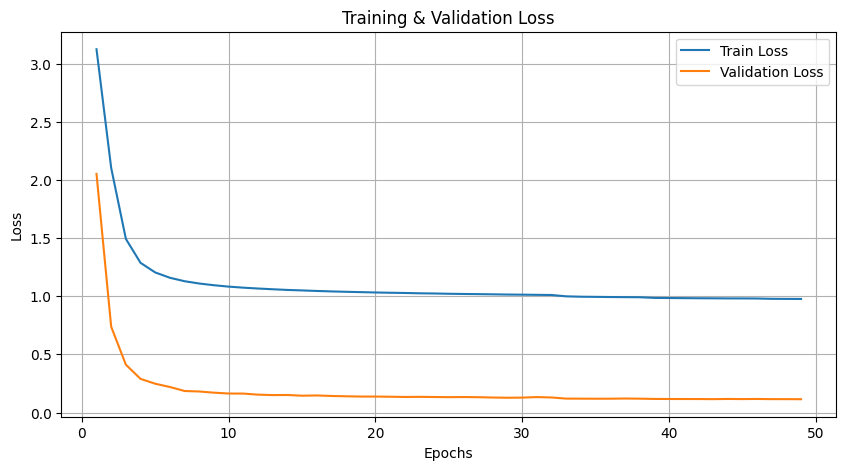

In [ ]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(10, 5))

# Truyền 'epochs' vào làm trục x
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")

plt.title("Training & Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)
plt.savefig("./training_validation_loss_plot.png")
plt.show()

# 5. EVALUATION


## 5.1 Utils


### 5.1.1 Utils for decoding


In [ ]:
# Code borrow from https://github.com/luopeixiang/im2latex/blob/master/model/beam_search.py
class BeamSearch:
    """
    Implements the beam search algorithm for decoding the most likely sequences.

    Parameters
    ----------
    end_index : ``int``
        The index of the "stop" or "end" token in the target vocabulary.
    max_steps : ``int``, optional (default = 50)
        The maximum number of decoding steps to take, i.e. the maximum length
        of the predicted sequences.
    beam_size : ``int``, optional (default = 10)
        The width of the beam used.
    per_node_beam_size : ``int``, optional (default = beam_size)
        The maximum number of candidates to consider per node, at each step in the search.
        If not given, this just defaults to ``beam_size``. Setting this parameter
        to a number smaller than ``beam_size`` may give better results,
        as it can introduce more diversity into the search.
        See `Beam Search Strategies for Neural Machine Translation.
        Freitag and Al-Onaizan, 2017 <http://arxiv.org/abs/1702.01806>`_.
    """

    def __init__(
        self,
        end_index: int,
        max_steps: int = 50,
        beam_size: int = 10,
        per_node_beam_size: int = None,
    ) -> None:
        self._end_index = end_index
        self.max_steps = max_steps
        self.beam_size = beam_size
        self.per_node_beam_size = per_node_beam_size or beam_size

    def search(self, start_predictions, start_state, step):
        """
        Given a starting state and a step function, apply beam search to find the
        most likely target sequences.

        Notes
        -----
        If your step function returns ``-inf`` for some log probabilities
        (like if you're using a masked log-softmax) then some of the "best"
        sequences returned may also have ``-inf`` log probability. Specifically
        this happens when the beam size is smaller than the number of actions
        with finite log probability (non-zero probability) returned by the step function.
        Therefore if you're using a mask you may want to check the results from ``search``
        and potentially discard sequences with non-finite log probability.

        Parameters
        ----------
        start_predictions : ``torch.Tensor``
            A tensor containing the initial predictions with shape ``(batch_size,)``.
            Usually the initial predictions are just the index of the "start" token
            in the target vocabulary.
        start_state : ``dict``
            The initial state passed to the ``step`` function.
            Each value of the state dict should be a tensor of shape ``(batch_size, *)``,
            where ``*`` means any other number of dimensions.
        step : ``function``
            A function that is responsible for computing the next most likely tokens,
            given the current state and the predictions from the last time step.
            The function should accept two arguments. The first being a tensor
            of shape ``(group_size,)``, representing the index of the predicted
            tokens from the last time step, and the second being the current state.
            The ``group_size`` will be ``batch_size * beam_size``, except in the initial
            step, for which it will just be ``batch_size``.
            The function is expected to return a tuple, where the first element
            is a tensor of shape ``(group_size, target_vocab_size)`` containing
            the log probabilities of the tokens for the next step, and the second
            element is the updated state. The tensor in the state should have shape
            ``(group_size, *)``, where ``*`` means any other number of dimensions.

        Returns
        -------
        Tuple[torch.Tensor, torch.Tensor]
            Tuple of ``(predictions, log_probabilities)``, where ``predictions``
            has shape ``(batch_size, beam_size, max_steps)`` and ``log_probabilities``
            has shape ``(batch_size, beam_size)``.
        """
        batch_size = start_predictions.size()[0]

        # List of (batch_size, beam_size) tensors. One for each time step. Does not
        # include the start symbols, which are implicit.
        predictions = []

        # List of (batch_size, beam_size) tensors. One for each time step. None for
        # the first.  Stores the index n for the parent prediction, i.e.
        # predictions[t-1][i][n], that it came from.
        backpointers = []

        # Calculate the first timestep. This is done outside the main loop
        # because we are going from a single decoder input (the output from the
        # encoder) to the top `beam_size` decoder outputs. On the other hand,
        # within the main loop we are going from the `beam_size` elements of the
        # beam to `beam_size`^2 candidates from which we will select the top
        # `beam_size` elements for the next iteration.
        # shape: (batch_size, num_classes)
        start_class_log_probabilities, state = step(start_predictions, start_state)

        num_classes = start_class_log_probabilities.size()[1]

        # shape: (batch_size, beam_size), (batch_size, beam_size)
        start_top_log_probabilities, start_predicted_classes = (
            start_class_log_probabilities.topk(self.beam_size)
        )
        if self.beam_size == 1 and (start_predicted_classes == self._end_index).all():
            print(
                "Empty sequences predicted. You may want to "
                "increase the beam size or ensure "
                "your step function is working properly."
            )
            return start_predicted_classes.unsqueeze(-1), start_top_log_probabilities

        # The log probabilities for the last time step.
        # shape: (batch_size, beam_size)
        last_log_probabilities = start_top_log_probabilities

        # shape: [(batch_size, beam_size)]
        predictions.append(start_predicted_classes)

        # Log probability tensor that mandates that the end token is selected.
        # shape: (batch_size * beam_size, num_classes)
        log_probs_after_end = start_class_log_probabilities.new_full(
            (batch_size * self.beam_size, num_classes), float("-inf")
        )
        log_probs_after_end[:, self._end_index] = 0.0

        # Set the same state for each element in the beam.
        for key, state_tensor in state.items():
            _, *last_dims = state_tensor.size()
            # shape: (batch_size * beam_size, *)
            state[key] = (
                state_tensor.unsqueeze(1)
                .expand(batch_size, self.beam_size, *last_dims)
                .reshape(batch_size * self.beam_size, *last_dims)
            )

        for timestep in range(self.max_steps - 1):
            # shape: (batch_size * beam_size,)
            last_predictions = predictions[-1].reshape(batch_size * self.beam_size)

            # If every predicted token from the last step is `self._end_index`,
            # then we can stop early.
            if (last_predictions == self._end_index).all():
                break

            # Take a step. This get the predicted log probs of the next classes
            # and updates the state.
            # shape: (batch_size * beam_size, num_classes)
            class_log_probabilities, state = step(last_predictions, state)

            # shape: (batch_size * beam_size, num_classes)
            last_predictions_expanded = last_predictions.unsqueeze(-1).expand(
                batch_size * self.beam_size, num_classes
            )

            # Here we are finding any beams where we predicted the end token in
            # the previous timestep and replacing the distribution with a
            # one-hot distribution, forcing the beam to predict the end token
            # this timestep as well.
            # shape: (batch_size * beam_size, num_classes)
            cleaned_log_probabilities = torch.where(
                last_predictions_expanded == self._end_index,
                log_probs_after_end,
                class_log_probabilities,
            )

            # shape (both): (batch_size * beam_size, per_node_beam_size)
            top_log_probabilities, predicted_classes = cleaned_log_probabilities.topk(
                self.per_node_beam_size
            )

            # Here we expand the last log probabilities to (batch_size * beam_size, per_node_beam_size)
            # so that we can add them to the current log probs for this timestep.
            # This lets us maintain the log probability of each element on the beam.
            # shape: (batch_size * beam_size, per_node_beam_size)
            expanded_last_log_probabilities = (
                last_log_probabilities.unsqueeze(2)
                .expand(batch_size, self.beam_size, self.per_node_beam_size)
                .reshape(batch_size * self.beam_size, self.per_node_beam_size)
            )

            # shape: (batch_size * beam_size, per_node_beam_size)
            summed_top_log_probabilities = (
                top_log_probabilities + expanded_last_log_probabilities
            )

            # shape: (batch_size, beam_size * per_node_beam_size)
            reshaped_summed = summed_top_log_probabilities.reshape(
                batch_size, self.beam_size * self.per_node_beam_size
            )

            # shape: (batch_size, beam_size * per_node_beam_size)
            reshaped_predicted_classes = predicted_classes.reshape(
                batch_size, self.beam_size * self.per_node_beam_size
            )

            # Keep only the top `beam_size` beam indices.
            # shape: (batch_size, beam_size), (batch_size, beam_size)
            restricted_beam_log_probs, restricted_beam_indices = reshaped_summed.topk(
                self.beam_size
            )

            # Use the beam indices to extract the corresponding classes.
            # shape: (batch_size, beam_size)
            restricted_predicted_classes = reshaped_predicted_classes.gather(
                1, restricted_beam_indices
            )

            predictions.append(restricted_predicted_classes)

            # shape: (batch_size, beam_size)
            last_log_probabilities = restricted_beam_log_probs

            # The beam indices come from a `beam_size * per_node_beam_size` dimension where the
            # indices with a common ancestor are grouped together. Hence
            # dividing by per_node_beam_size gives the ancestor. (Note that this is integer
            # division as the tensor is a LongTensor.)
            # shape: (batch_size, beam_size)
            backpointer = restricted_beam_indices // self.per_node_beam_size

            backpointers.append(backpointer)

            # Keep only the pieces of the state tensors corresponding to the
            # ancestors created this iteration.
            for key, state_tensor in state.items():
                _, *last_dims = state_tensor.size()
                # shape: (batch_size, beam_size, *)
                expanded_backpointer = backpointer.view(
                    batch_size, self.beam_size, *([1] * len(last_dims))
                ).expand(batch_size, self.beam_size, *last_dims)

                # shape: (batch_size * beam_size, *)
                state[key] = (
                    state_tensor.reshape(batch_size, self.beam_size, *last_dims)
                    .gather(1, expanded_backpointer)
                    .reshape(batch_size * self.beam_size, *last_dims)
                )

        if not torch.isfinite(last_log_probabilities).all():
            print(
                "Infinite log probabilities encountered. "
                "Some final sequences may not make sense. "
                "This can happen when the beam size is "
                "larger than the number of valid (non-zero "
                "probability) transitions that the step function produces."
            )

        # Reconstruct the sequences.
        # shape: [(batch_size, beam_size, 1)]
        reconstructed_predictions = [predictions[-1].unsqueeze(2)]

        # shape: (batch_size, beam_size)
        cur_backpointers = backpointers[-1]

        for timestep in range(len(predictions) - 2, 0, -1):
            # shape: (batch_size, beam_size, 1)
            cur_preds = predictions[timestep].gather(1, cur_backpointers).unsqueeze(2)

            reconstructed_predictions.append(cur_preds)

            # shape: (batch_size, beam_size)
            cur_backpointers = backpointers[timestep - 1].gather(1, cur_backpointers)

        # shape: (batch_size, beam_size, 1)
        final_preds = predictions[0].gather(1, cur_backpointers).unsqueeze(2)

        reconstructed_predictions.append(final_preds)

        # shape: (batch_size, beam_size, max_steps)
        all_predictions = torch.cat(list(reversed(reconstructed_predictions)), 2)

        return all_predictions, last_log_probabilities

In [ ]:
class LatexProducer(object):
    """
    Model wrapper, implementing batch greedy decoding and
    batch beam search decoding
    """

    def __init__(self, model, vocab, beam_size=5, max_len=64, use_cuda=True):
        """args:
        the path to model checkpoint
        """
        self.device = torch.device("cuda" if use_cuda else "cpu")
        self.model = model.to(self.device)
        self._sign2id = vocab.sign2id
        self._id2sign = vocab.id2sign
        self.max_len = max_len
        self.beam_size = beam_size
        self._beam_search = BeamSearch(END_TOKEN_ID, max_len, beam_size)

    def __call__(self, imgs):
        """args:
         imgs: images need to be decoded
         beam_size: if equal to 1, use greedy decoding
        returns:
         formulas list of batch_size length
        """
        if self.beam_size == 1:
            results = self._greedy_decoding(imgs)
        else:
            results = self._batch_beam_search(imgs)
        return results

    def _idx2formulas(self, formulas_idx):
        """convert formula id matrix to formulas list"""
        results = []
        for formula in formulas_idx:
            formula = formula.tolist()
            result = []
            for idx in formula:
                if idx == END_TOKEN_ID:
                    break
                if idx != START_TOKEN_ID and idx != PAD_TOKEN_ID:
                    result.append(self._id2sign[idx])
            results.append(" ".join(result))
        return results

    def _greedy_decoding(self, imgs):
        self.model.eval()
        imgs = imgs.to(self.device)

        enc_out = self.model.encoder(imgs)
        precomputed_enc_kv = self.model.decoder.precompute_encoder_kv(enc_out)

        batch_size = imgs.size(0)
        # first decoding step's input
        generated = torch.full(
            (batch_size,), START_TOKEN_ID, dtype=torch.long, device=device
        )
        with torch.no_grad():
            for t in range(self.max_len):
                logit, _ = self.model.decoder(
                    generated, enc_out, precomputed_enc_kv=precomputed_enc_kv
                )
                next_token = torch.argmax(logit[:, -1:, :], dim=-1)
                generated = torch.cat([generated, next_token], dim=1)
                if (next_token == END_TOKEN_ID).all():
                    break
        return self._idx2formulas(generated)

    def _batch_beam_search(self, imgs):
        self.model.eval()
        imgs = imgs.to(self.device)
        batch_size = imgs.size(0)

        with torch.no_grad():
            # 1. Encode một lần
            enc_out = self.model.encoder(imgs)
            precomputed_enc_kv = self.model.decoder.precompute_encoder_kv(enc_out)

            start_predictions = torch.full(
                (batch_size,), START_TOKEN_ID, dtype=torch.long, device=self.device
            )

            # 2. State chỉ chứa encoder KV + past self-attention KV
            start_state = {
                "enc_out": enc_out,
            }

            # Encoder KV (không đổi suốt quá trình)
            for i, (k, v) in enumerate(precomputed_enc_kv):
                start_state[f"enc_k_{i}"] = k
                start_state[f"enc_v_{i}"] = v

            # Decoder self-attention KV cache (khởi tạo rỗng)
            num_layers = len(self.model.decoder.layers)
            for i in range(num_layers):
                start_state[f"self_k_{i}"] = None
                start_state[f"self_v_{i}"] = None

            predictions, log_probs = self._beam_search.search(
                start_predictions, start_state, self._take_step
            )

            best_predictions = predictions[:, 0, :]

        return self._idx2formulas(best_predictions)

    def _take_step(self, last_predictions, state):
        """
        QUAN TRỌNG: Mỗi step chỉ decode 1 token mới, tái sử dụng KV cache
        """
        enc_out = state["enc_out"]

        # Reconstruct encoder KV
        num_layers = sum(1 for key in state.keys() if key.startswith("enc_k_"))
        enc_kv = [(state[f"enc_k_{i}"], state[f"enc_v_{i}"]) for i in range(num_layers)]

        # Reconstruct decoder self-attention KV cache
        past_self_kvs = []
        for i in range(num_layers):
            k = state[f"self_k_{i}"]
            v = state[f"self_v_{i}"]
            if k is not None and v is not None:
                past_self_kvs.append((k, v))
            else:
                past_self_kvs.append(None)

        # CHỈ DECODE 1 TOKEN MỚI (không phải cả history!)
        input_tokens = last_predictions.unsqueeze(1)  # [group_size, 1]

        # Forward với KV cache
        logits, present_self_kvs = self._forward_with_cache(
            input_tokens, enc_out, enc_kv, past_self_kvs
        )

        log_probs = torch.nn.functional.log_softmax(logits[:, -1, :], dim=-1)

        # Update state với KV mới
        new_state = {"enc_out": enc_out}

        # Encoder KV không đổi
        for i in range(num_layers):
            new_state[f"enc_k_{i}"] = state[f"enc_k_{i}"]
            new_state[f"enc_v_{i}"] = state[f"enc_v_{i}"]

        # Decoder self-attention KV được update
        for i in range(num_layers):
            if present_self_kvs[i] is not None:
                new_state[f"self_k_{i}"] = present_self_kvs[i][0]
                new_state[f"self_v_{i}"] = present_self_kvs[i][1]
            else:
                new_state[f"self_k_{i}"] = None
                new_state[f"self_v_{i}"] = None

        return log_probs, new_state

    def _forward_with_cache(self, tgt, enc_out, precomputed_enc_kv, past_self_kvs):
        """
        Custom forward pass với KV cache cho beam search
        """
        # Embedding
        tgt_emb = self.model.decoder.embedding(tgt) * self.model.decoder.embedding_scale
        tgt_emb = self.model.decoder.pos_encoding(tgt_emb)
        tgt_emb = self.model.decoder.dropout(tgt_emb)

        # Không cần mask vì chỉ decode 1 token
        x = tgt_emb
        present_self_kvs = []

        for i, layer in enumerate(self.model.decoder.layers):
            # Self-attention với cache
            attn_out, _, present_kv = layer.self_attn(
                x,
                x,
                x,
                mask=None,  # Decode 1 token không cần mask
                past_kv=past_self_kvs[i],
                use_cache=True,
            )
            x = layer.norm1(x + layer.dropout(attn_out))

            # Cross-attention với precomputed encoder KV
            attn_out, _, _ = layer.cross_attn(
                x, enc_out, enc_out, mask=None, precomputed_kv=precomputed_enc_kv[i]
            )
            x = layer.norm2(x + layer.dropout(attn_out))

            # FFN
            ffn_out = layer.ffn(x)
            x = layer.norm3(x + layer.dropout(ffn_out))

            present_self_kvs.append(present_kv)

        logits = self.model.decoder.fc_out(x)
        return logits, present_self_kvs

### 5.2.2 Utils for calc score


In [ ]:
def score_files(path_ref, path_hyp):
    """Loads result from file and score it

    Args:
        path_ref: (string) formulas of reference
        path_hyp: (string) formulas of prediction.

    Returns:
        scores: (dict)

    """
    # load formulas
    formulas_ref = load_formulas(path_ref)
    formulas_hyp = load_formulas(path_hyp)

    assert len(formulas_ref) == len(formulas_hyp)

    # tokenize
    refs = [ref.split(" ") for _, ref in formulas_ref.items()]
    hyps = [hyp.split(" ") for _, hyp in formulas_hyp.items()]

    # score
    return {
        "BLEU-4": bleu_score(refs, hyps) * 100,
        "EM": exact_match_score(refs, hyps) * 100,
        "Edit": edit_distance(refs, hyps) * 100,
    }


def exact_match_score(references, hypotheses):
    """Computes exact match scores.

    Args:
        references: list of list of tokens (one ref)
        hypotheses: list of list of tokens (one hypothesis)

    Returns:
        exact_match: (float) 1 is perfect

    """
    exact_match = 0
    for ref, hypo in zip(references, hypotheses):
        if np.array_equal(ref, hypo):
            exact_match += 1

    return exact_match / float(max(len(hypotheses), 1))


def bleu_score(references, hypotheses):
    """Computes bleu score.

    Args:
        references: list of list (one hypothesis)
        hypotheses: list of list (one hypothesis)

    Returns:
        BLEU-4 score: (float)

    """
    references = [[ref] for ref in references]  # for corpus_bleu func
    BLEU_4 = nltk.translate.bleu_score.corpus_bleu(
        references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25)
    )
    return BLEU_4


def edit_distance(references, hypotheses):
    """Computes Levenshtein distance between two sequences.

    Args:
        references: list of list of token (one hypothesis)
        hypotheses: list of list of token (one hypothesis)

    Returns:
        1 - levenshtein distance: (higher is better, 1 is perfect)

    """
    d_leven, len_tot = 0, 0
    for ref, hypo in zip(references, hypotheses):
        d_leven += distance.levenshtein(ref, hypo)
        len_tot += float(max(len(ref), len(hypo)))

    return 1.0 - d_leven / len_tot


def load_formulas(filename):
    formulas = dict()
    with open(filename) as f:
        for idx, line in enumerate(f):
            formulas[idx] = line.strip()
    print("Loaded {} formulas from {}".format(len(formulas), filename))
    return formulas

## 5.2 Perform evaluation


**Load best model**


In [ ]:
checkpoint_path = get_checkpoint(args.save_dir, "best")
checkpoint = torch.load(checkpoint_path, weights_only=False)

model_args = checkpoint["args"]

Found best checkpoint: ./Checkpoint/best_model.pt


In [ ]:
eval_model = Im2LatexModel(
    vocab_size=vocab_size,
    d_model=args.d_model,
    n_heads=args.n_heads,
    n_layers=args.n_layers,
    d_ff=args.d_ff,
    max_len=args.max_len + 1,
    dropout=args.dropout,
    pad_idx=PAD_TOKEN_ID,
)

eval_model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

**Decoding**


In [ ]:
result_file = open(args.result_path, "w")
ref_file = open(args.ref_path, "w")

latex_producer = LatexProducer(
    eval_model, vocab, max_len=args.max_len, use_cuda=use_cuda, beam_size=args.beam_size
)

for imgs, formulas in tqdm(test_loader):
    try:
        tgt4cal_loss = formulas[:, 1:]
        reference = latex_producer._idx2formulas(tgt4cal_loss)
        results = latex_producer(imgs)
    except RuntimeError as e:
        print(f"\nĐã xảy ra lỗi tại batch này: {e}")
        traceback.print_exc()
        break

    result_file.write("\n".join(results))
    ref_file.write("\n".join(reference))

result_file.close()
ref_file.close()

  0%|          | 0/323 [00:00<?, ?it/s]

**Scoring**


In [41]:
score = score_files(args.result_path, args.ref_path)
print("beam search result:", score)

Loaded 9606 formulas from ./Result.txt
Loaded 9606 formulas from ./Ref.txt
beam search result: {'BLEU-4': 91.46029472205254, 'EM': 46.94982302727462, 'Edit': 93.86518509931857}
